In [2]:
pip install pyodbc pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import pyodbc

In [19]:
# connection string 
conn=pyodbc.connect(
    'Driver={SQL Server};'
    'Server=KOMAL\SQLEXPRESS;'
    'Database=Ecommerce_Analytics_project;'
    'Trusted_connection=yes;'
)
# create curson
cursor=conn.cursor()

In [20]:
sessions = pd.read_sql("SELECT * FROM website_sessions", conn)
orders = pd.read_sql("SELECT * FROM orders", conn)
order_items = pd.read_sql("SELECT * FROM orders_items", conn)
products = pd.read_sql("SELECT * FROM products", conn)
refunds = pd.read_sql("SELECT * FROM order_item_refunds", conn)
website_pageviews = pd.read_sql("SELECT * FROM website_pageviews", conn)

C:\Users\acer\AppData\Local\Temp\ipykernel_27840\2436646504.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sessions = pd.read_sql("SELECT * FROM website_sessions", conn)
C:\Users\acer\AppData\Local\Temp\ipykernel_27840\2436646504.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql("SELECT * FROM orders", conn)
C:\Users\acer\AppData\Local\Temp\ipykernel_27840\2436646504.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_items = pd.read_sql("SELECT * FROM orders_items", conn)
C:\Users\acer\App

In [21]:
print(sessions.head())
print(orders.head())
print(order_items.head())
print(products.head())
print(refunds.head())
print(website_pageviews.head())

   website_session_id          created_at  user_id  is_repeat_session  \
0                   1 2012-03-19 08:04:16        1                  0   
1                   2 2012-03-19 08:16:49        2                  0   
2                   3 2012-03-19 08:26:55        3                  0   
3                   4 2012-03-19 08:37:33        4                  0   
4                   5 2012-03-19 09:00:55        5                  0   

  utm_source utm_campaign utm_content device_type             http_referer  
0    gsearch     nonbrand      g_ad_1      mobile  https://www.gsearch.com  
1    gsearch     nonbrand      g_ad_1     desktop  https://www.gsearch.com  
2    gsearch     nonbrand      g_ad_1     desktop  https://www.gsearch.com  
3    gsearch     nonbrand      g_ad_1     desktop  https://www.gsearch.com  
4    gsearch     nonbrand      g_ad_1      mobile  https://www.gsearch.com  
   order_id          created_at  website_session_id  user_id  \
0         1 2012-03-19 10:42:46    

In [64]:
# now fixing outliers  
#--orders table
for col in ['price_usd','cogs_usd','items_purchased']:
    q1=orders[col].quantile(0.25)
    q3=orders[col].quantile(0.75)
    iqr=q3-q1
    lower=max(q1-1.5*iqr,0)
    upper=q3+1.5*iqr

    flag_col=col+"_was_outlier"
    orders[flag_col]=(orders[col]<lower)|(orders[col]>upper)
    n_flagged=orders[flag_col].sum()

    orders[col]=orders[col].clip(lower=lower,upper=upper)
    print(f'orders.{col}:bounds=({lower:.2f},{upper:.2f}),{n_flagged} rows capped')
    

orders.price_usd:bounds=(34.99,74.99),0 rows capped
orders.cogs_usd:bounds=(14.99,26.99),0 rows capped
orders.items_purchased:bounds=(1.00,1.00),0 rows capped


In [65]:
# order_items
for col in ['price_usd','cogs_usd']:
    q1=order_items[col].quantile(0.25)
    q3=order_items[col].quantile(0.75)
    iqr=q3-q1
    lower=max(q1-1.5*iqr,0)
    upper=q3+1.5*iqr

    flag_col=col+"_was_outlier"
    order_items[flag_col]=(order_items[col]<lower)|(order_items[col]>upper)
    n_flagged=order_items[flag_col].sum()

    order_items[col]=order_items[col].clip(lower=lower,upper=upper)
    print(f'order_items.{col}:bounds=({lower:.2f},{upper:.2f}),{n_flagged} rows capped')

order_items.price_usd:bounds=(49.99,49.99),0 rows capped
order_items.cogs_usd:bounds=(19.49,19.49),0 rows capped


In [66]:
# order item refund
col = 'refund_amount_usd'
q1=refunds[col].quantile(0.25)
q3=refunds[col].quantile(0.75)
iqr=q3-q1
lower=max(q1-1.5*iqr,0)
upper=q3+1.5*iqr

flag_col=col+"_was_outlier"
refunds[flag_col]=(refunds[col]<lower)|(refunds[col]>upper)
n_flagged=refunds[flag_col].sum()

refunds[col]=refunds[col].clip(lower=lower,upper=upper)
print(f'refunds.{col}:bounds=({lower:.2f},{upper:.2f}),{n_flagged} rows capped')

refunds.refund_amount_usd:bounds=(49.99,49.99),0 rows capped


### DESCRIPTIVE ANALYSIS (what happened)

In [25]:
total_revenue=order_items['price_usd'].sum()
total_refund=refunds['refund_amount_usd'].sum()
net_revenue=total_revenue-total_refund

In [26]:
total_cogs=order_items['cogs_usd'].sum()
gross_margin=total_revenue-total_cogs
gros_margin_perc=gross_margin/total_revenue*1000

In [27]:
total_orders=orders['order_id'].nunique()
total_session=sessions['website_session_id'].nunique()
conversion_rate=total_orders/total_session*100
avg_value_order=orders['price_usd'].sum()/total_orders

In [28]:
print('total_revenue:',round(total_revenue,2))
print('total_refund:',round(total_refund,2))
print('net_revenue:',round(net_revenue,2))
print('total_cogs:',round(total_cogs,2))
print('gross_margin:',round(gross_margin,2))
print('gros_margin_%:',round(gros_margin_perc,2))
print('conversion_rate_%:',round(conversion_rate,2))
print('total_orders:',total_revenue)
print('total_session:',total_revenue)
print('Avg order value:', round(avg_value_order, 2))

total_revenue: 2000849.75
total_refund: 86532.69
net_revenue: 1914317.06
total_cogs: 780087.25
gross_margin: 1220762.5
gros_margin_%: 610.12
conversion_rate_%: 6.83
total_orders: 2000849.75
total_session: 2000849.75
Avg order value: 54.28


In [29]:
# monthly sales & revenue trend 
order_items['months']=order_items['created_at'].dt.to_period('M').astype(str)
monthly_revenue=order_items.groupby('months')['price_usd'].sum().reset_index()
monthly_revenue=monthly_revenue.sort_values('months')
monthly_revenue['sales_growth']=monthly_revenue['price_usd'].pct_change()
print('\n=====monthly revenue=====')
print(monthly_revenue.to_string(index=False))



=====monthly revenue=====
 months  price_usd  sales_growth
2012-03    2999.40           NaN
2012-04    4949.01      0.650000
2012-05    5398.92      0.090909
2012-06    6998.60      0.296296
2012-07    8448.31      0.207143
2012-08   11397.72      0.349112
2012-09   14347.13      0.258772
2012-10   18546.29      0.292683
2012-11   30893.82      0.665768
2012-12   25294.94     -0.181230
2013-01   19496.10     -0.229249
2013-02   24895.02      0.276923
2013-03   19246.15     -0.226908
2013-04   27644.47      0.436364
2013-05   28544.29      0.032550
2013-06   29644.07      0.038529
2013-07   30193.96      0.018550
2013-08   30393.92      0.006623
2013-09   31743.65      0.044408
2013-10   36892.62      0.162205
2013-11   44891.02      0.216802
2013-12   56988.60      0.269488
2014-01   55538.89     -0.025439
2014-02   67386.52      0.213321
2014-03   71335.73      0.058605
2014-04   82833.43      0.161177
2014-05   93631.27      0.130356
2014-06   83733.25     -0.105713
2014-07   87232.

In [30]:
# monthly session trend 
'''  Does traffic track with revenue month to month, or do they move independently'''
sessions['months']=sessions['created_at'].dt.to_period('M').astype(str)
monthly_sessions=sessions.groupby('months').size().reset_index(name='sessions')
monthly_sessions=monthly_sessions.sort_values('months')
print('\n=====monthly revenue=====')
print(monthly_sessions.to_string(index=False))

busy_month=monthly_sessions.loc[monthly_sessions['sessions'].idxmax()]
quite_month=monthly_sessions.loc[monthly_sessions['sessions'].idxmin()]
print(f"insights:{busy_month['months']} had the traffic ({busy_month['sessions']} sessions),"
      f"{quite_month['months']}had the least ({quite_month['sessions']} sessions).")



=====monthly revenue=====
 months  sessions
2012-03      1879
2012-04      3734
2012-05      3736
2012-06      3963
2012-07      4249
2012-08      6097
2012-09      6546
2012-10      8183
2012-11     14011
2012-12     10072
2013-01      6401
2013-02      7168
2013-03      6264
2013-04      7971
2013-05      8449
2013-06      8325
2013-07      8903
2013-08      9180
2013-09      9580
2013-10     10773
2013-11     14032
2013-12     15735
2014-01     14825
2014-02     16285
2014-03     15669
2014-04     17353
2014-05     18061
2014-06     17715
2014-07     19038
2014-08     18590
2014-09     19513
2014-10     21526
2014-11     25125
2014-12     29722
2015-01     25337
2015-02     23778
2015-03     15083
insights:2014-12 had the traffic (29722 sessions),2012-03had the least (1879 sessions).


In [31]:
#revenue by channel 
merged=sessions[['website_session_id','utm_source']].merge(orders[['order_id','website_session_id']],on='website_session_id')
merged=merged.merge(order_items[['order_id','price_usd']],on='order_id')
revenue_by_source=merged.groupby('utm_source').agg(
    orders=('order_id','nunique'),revenue=('price_usd','sum')).reset_index().sort_values('revenue',ascending=False)
print('\n======revenue by channel======')
print(revenue_by_source.to_string(index=False))


======revenue by channel======
utm_source  orders    revenue
   gsearch   21333 1315286.89
   unknown    6118  384773.03
   bsearch    4519  277444.50
socialbook     343   23345.33


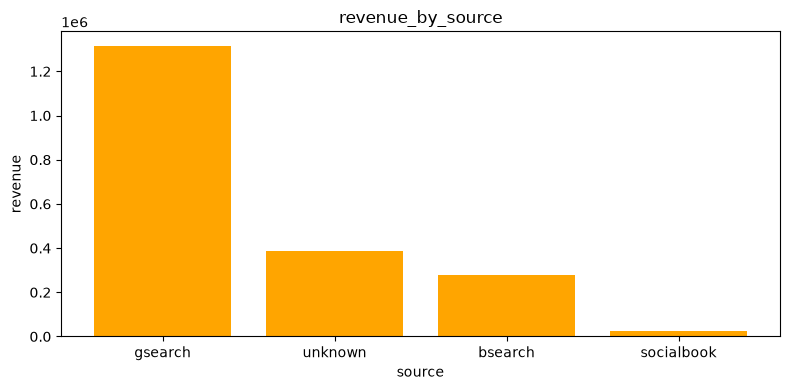

insights:gsearch brings in the most revenue(1315286.89 from 21333 orders).


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns 
plt.figure(figsize=(8,4))
plt.bar(revenue_by_source['utm_source'],revenue_by_source['revenue'],color='orange')
plt.title('revenue_by_source')
plt.xlabel('source')
plt.ylabel('revenue')
plt.tight_layout()
plt.show()

top_source=revenue_by_source.iloc[0]
print(f"insights:{top_source['utm_source']} brings in the most revenue"
      f"({top_source['revenue']:.2f} from {top_source['orders']} orders).")

In [34]:
#revenue by device 
merged2=sessions[['website_session_id','device_type']].merge(orders[['order_id','website_session_id']],on='website_session_id')
merged2=merged2.merge(order_items[['order_id','price_usd']],on='order_id')
revenue_by_device=merged2.groupby('device_type').agg(
    orders=('order_id','nunique'),revenue=('price_usd','sum')).reset_index().sort_values('revenue',ascending=False)
print('\n======revenue by device======')
print(revenue_by_device.to_string(index=False))


======revenue by device======
device_type  orders    revenue
    desktop   27805 1720455.84
     mobile    4508  280393.91


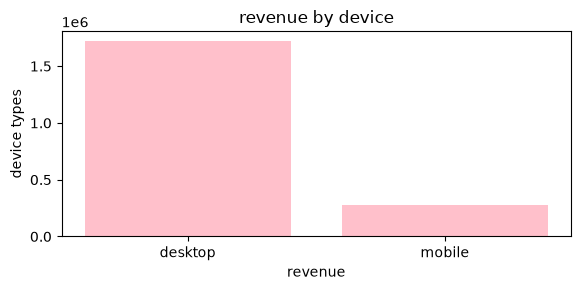

Insight: desktop generates the most revenue (1720455.84).


In [35]:
plt.figure(figsize=(6,3))
plt.bar(revenue_by_device['device_type'],revenue_by_device['revenue'],color='pink')
plt.title('revenue by device')
plt.xlabel('revenue')
plt.ylabel('device types')
plt.tight_layout()
plt.show()

top_device = revenue_by_device.iloc[0]
print(f"Insight: {top_device['device_type']} generates the most revenue "
      f"({top_device['revenue']:.2f}).")

In [36]:
#top products
merged3=order_items.merge(products,on='product_id')
top_products=merged3.groupby('product_name').agg(
    units_sold=('order_item_id','nunique'),revenue=('price_usd','sum')).reset_index().sort_values('revenue',ascending=False)
print('\n======top produts=======')
print(top_products.to_string(index=False))


======top produts=======
              product_name  units_sold    revenue
    The Original Mr. Fuzzy       24226 1211057.74
     The Forever Love Bear        5796  289742.04
The Hudson River Mini bear        5018  250849.82
  The Birthday Sugar Panda        4985  249200.15


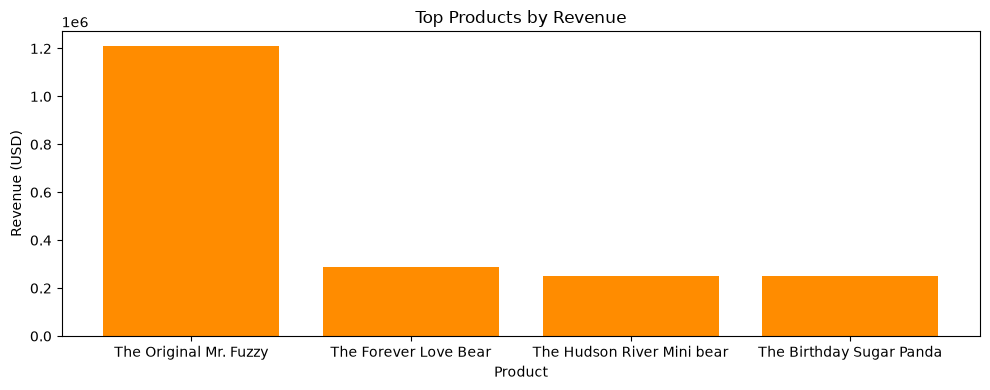

Insight: The Original Mr. Fuzzy is the top seller (1211057.74 from 24226 units).


In [37]:
plt.figure(figsize=(10, 4))
plt.bar(top_products["product_name"], top_products["revenue"], color="darkorange")
plt.title("Top Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue (USD)")
plt.tight_layout()
plt.show()

best_product = top_products.iloc[0]
print(f"Insight: {best_product['product_name']} is the top seller "
      f"({best_product['revenue']:.2f} from {best_product['units_sold']} units).")

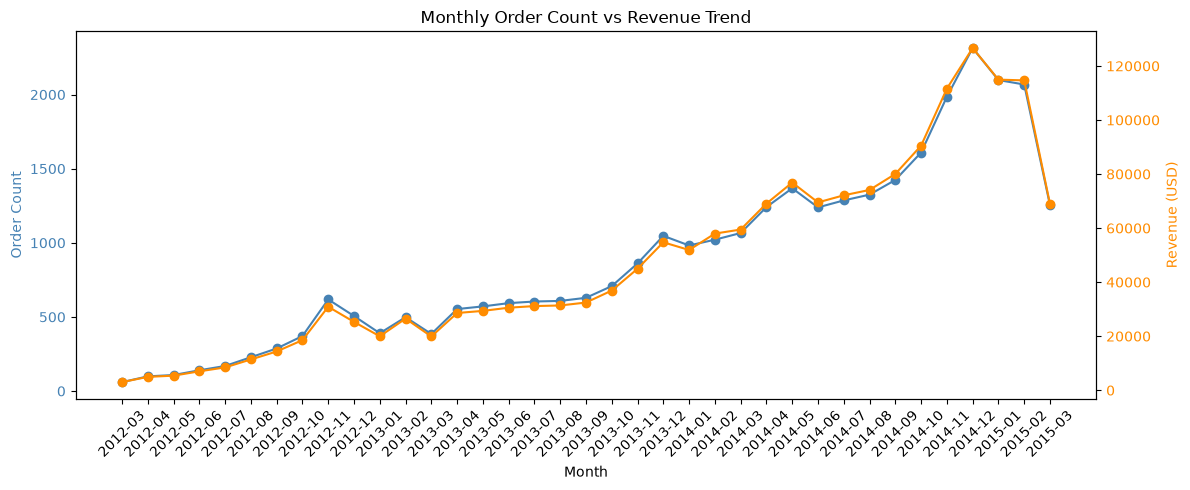

In [38]:
# ordertrend match the revenue trend
order_trend=orders.groupby(orders['created_at'].dt.to_period('M')).agg(
    order_count=('order_id','nunique'),
    revenue=('price_usd','sum')
)

order_trend = order_trend.reset_index()
order_trend['created_at'] = order_trend['created_at'].astype(str)  # Period -> string for clean x-axis

order_trend

fig, ax1 = plt.subplots(figsize=(12, 5))

# Order count line (left axis)
ax1.plot(order_trend['created_at'], order_trend['order_count'], 
         color='steelblue', marker='o', label='Order Count')
ax1.set_xlabel('Month')
ax1.set_ylabel('Order Count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
plt.xticks(rotation=45)

# Revenue line (right axis, since scale is very different)
ax2 = ax1.twinx()
ax2.plot(order_trend['created_at'], order_trend['revenue'], 
         color='darkorange', marker='o', label='Revenue')
ax2.set_ylabel('Revenue (USD)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Monthly Order Count vs Revenue Trend')
fig.tight_layout()
plt.show()

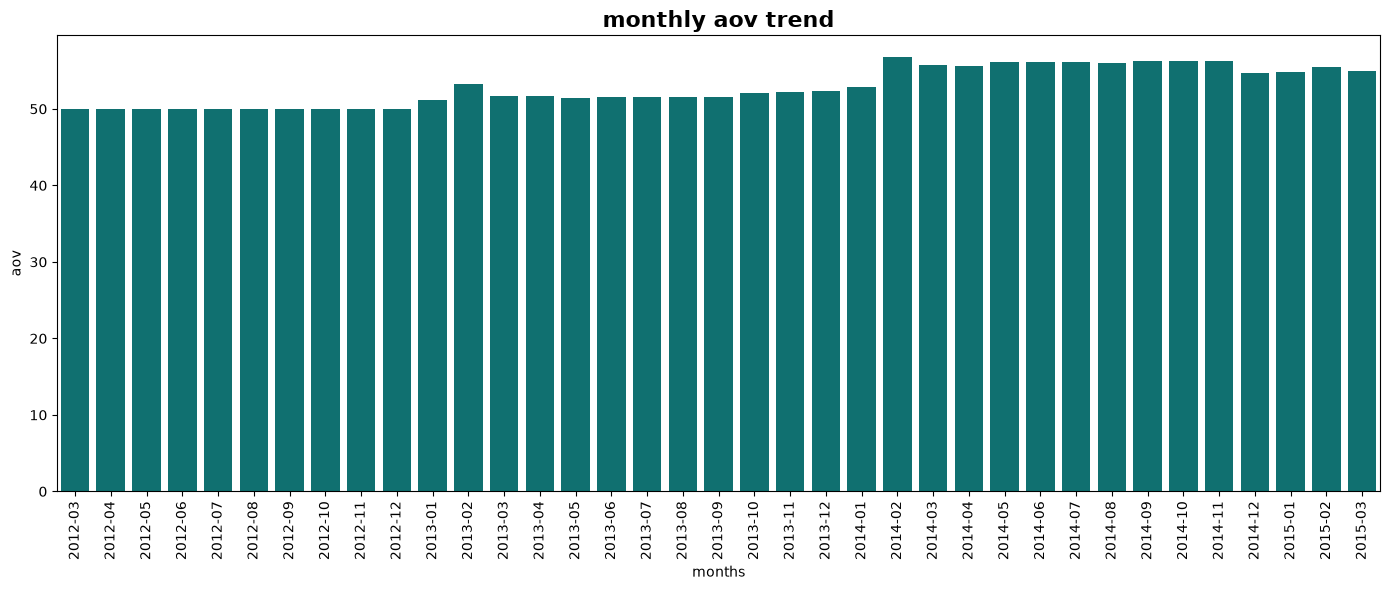

In [39]:
''' average order value trend '''
aov_trend=orders.groupby(orders['created_at'].dt.to_period('M')).agg(
    order_count=('order_id','nunique'),
    sales=('price_usd','sum')
).reset_index()
aov_trend['aov']=aov_trend['sales']/aov_trend['order_count']
aov_trend['months']=aov_trend['created_at'].astype(str)
aov_trend

plt.figure(figsize=(14,6))
sns.barplot(data=aov_trend,x='months',y='aov',color='teal')
plt.xticks(rotation=90)
plt.title('monthly aov trend',fontweight='bold',fontsize=16)
plt.tight_layout()
plt.show()


== price distribution ==
count    4.002500e+04
mean     4.999000e+01
std      8.555041e-12
min      4.999000e+01
25%      4.999000e+01
50%      4.999000e+01
75%      4.999000e+01
max      4.999000e+01

 ===== cost distribiution ======
count    4.002500e+04
mean     1.949000e+01
std      7.361315e-12
min      1.949000e+01
25%      1.949000e+01
50%      1.949000e+01
75%      1.949000e+01
max      1.949000e+01


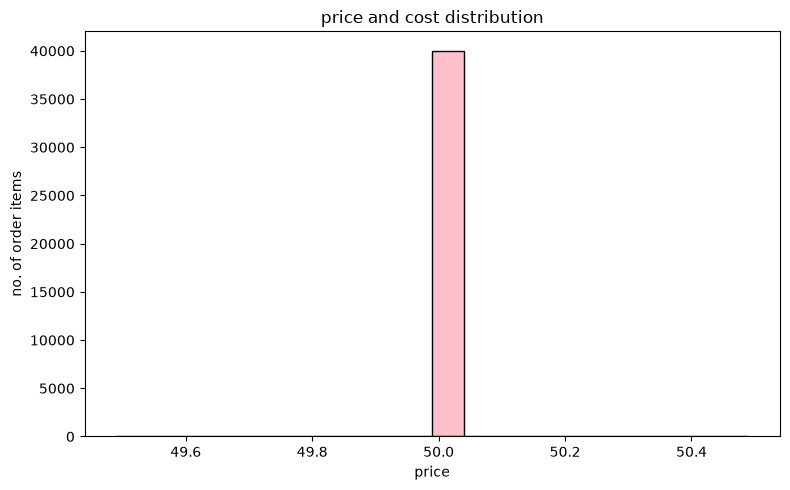

insights: typical item price sits around 49.99(median),ranging from $49.99 to $49.99.


In [40]:
# price and cost distribution (spread of the numbers,not just totals)
price_dist=order_items['price_usd'].describe()
cogs_dist=order_items['cogs_usd'].describe()
print('\n== price distribution ==')
print(price_dist.to_string())
print("\n ===== cost distribiution ======")
print(cogs_dist.to_string())

plt.figure(figsize=(8,5))
plt.hist(order_items['price_usd'],bins=20,color='pink',edgecolor='black')
plt.title('price and cost distribution')
plt.xlabel('price')
plt.ylabel('no. of order items')
plt.tight_layout()
plt.show()

print(f"insights: typical item price sits around {price_dist['50%']:.2f}(median),"
      f"ranging from ${price_dist['min']:.2f} to ${price_dist['max']:.2f}.")

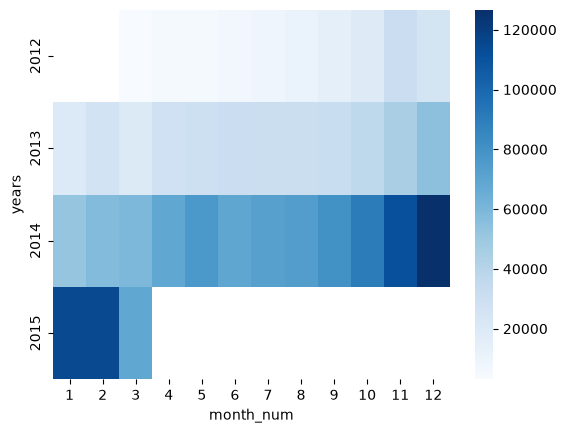

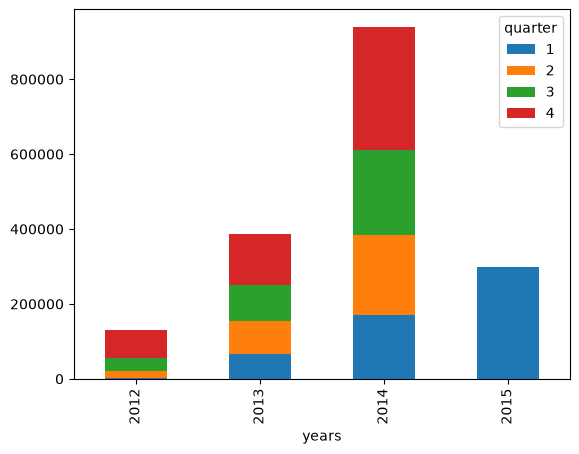

In [41]:
# revenue consistency check 
orders['years']=orders['created_at'].dt.year
orders['month_num']=orders['created_at'].dt.month
orders['quarter']=orders['created_at'].dt.quarter

heatmap_data=orders.pivot_table(
    index='years',
    columns='month_num',
    values='price_usd',
    aggfunc='sum'
)
sns.heatmap(heatmap_data,cmap='Blues')
plt.show()

quarter_data=orders.groupby(['years','quarter'])['price_usd'].sum().reset_index()
quarter_pivot=quarter_data.pivot(index='years',columns='quarter',values='price_usd')

quarter_pivot.plot(kind='bar',stacked=True)
plt.show()

/n ======= order size distribution ========
 items_purchased  num_orders
               1       32313


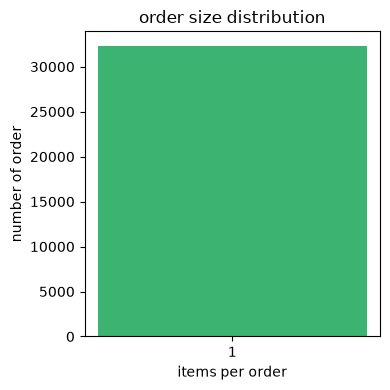

Insight: Most orders contain 1 item(s) (32313 orders).


In [42]:
order_size_distribution=orders['items_purchased'].value_counts().sort_index().reset_index()
order_size_distribution.columns=['items_purchased','num_orders']
print('/n ======= order size distribution ========')
print(order_size_distribution.to_string(index=False))
plt.figure(figsize=(4,4))
plt.bar(order_size_distribution['items_purchased'].astype(str),order_size_distribution['num_orders'],color='mediumseagreen')
plt.title('order size distribution')
plt.xlabel('items per order')
plt.ylabel('number of order')
plt.tight_layout()
plt.show()
most_common_size = order_size_distribution.loc[order_size_distribution["num_orders"].idxmax()]
print(f"Insight: Most orders contain {most_common_size['items_purchased']} item(s) "
      f"({most_common_size['num_orders']} orders).")


==== new vs reppeat session (visitor mix)=====
 label  pct_of_sessions  num_sessions
   new            83.39        394318
repeat            16.61         78553


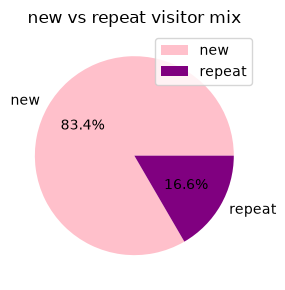

insights:repeat  visitors make up 16.61% of all sessions.


In [43]:
# New vs repeat visitor mix (raw counts, before tying to convers 
session_mix=sessions['is_repeat_session'].value_counts().reset_index()
session_mix.columns=['is_repeat_session','num_sessions']
session_mix['label']=session_mix['is_repeat_session'].map({0:"new",1:"repeat"})
session_mix['pct_of_sessions']=(session_mix['num_sessions']/session_mix['num_sessions'].sum()*100).round(2)
print('\n==== new vs reppeat session (visitor mix)=====')
print(session_mix[['label','pct_of_sessions','num_sessions']].to_string(index=False))
plt.figure(figsize=(5,3))
plt.pie(session_mix['num_sessions'],labels=session_mix['label'],autopct='%1.1f%%',colors=['pink','purple'])
plt.title('new vs repeat visitor mix')
plt.legend()
plt.tight_layout()
plt.show()

repeat_pct=session_mix.loc[session_mix['label']=='repeat','pct_of_sessions'].values[0]
print(f'insights:repeat  visitors make up {repeat_pct}% of all sessions.')


====monthly refund trend=====
  month  refund_amount_usd
2012-04             249.95
2012-05             249.95
2012-06             249.95
2012-07             649.87
2012-08             899.82
2012-09            1049.79
2012-10            1199.76
2012-11            1999.60
2012-12            1899.62
2013-01            1049.79
2013-02            1149.77
2013-03            1049.79
2013-04            1149.77
2013-05            1549.69
2013-06            1699.66
2013-07            2249.55
2013-08            1749.65
2013-09            1199.76
2013-10             949.81
2013-11             899.82
2013-12            2249.55
2014-01            1799.64
2014-02            2449.51
2014-03            2249.55
2014-04            2749.45
2014-05            2549.49
2014-06            3449.31
2014-07            3899.22
2014-08            4649.07
2014-09           11847.63
2014-10            2999.40
2014-11            3249.35
2014-12            6098.78
2015-01            4999.00
2015-02            3949.

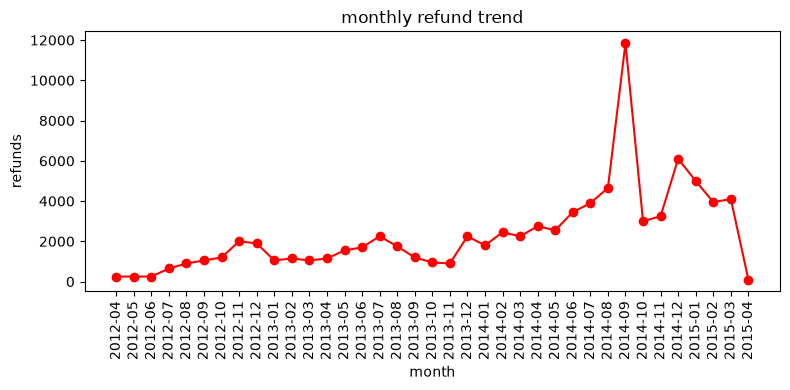

Insight: 2014-09 had the highest refund total ($11847.63).


In [44]:
# refund trend over time 
refunds['created_at']=pd.to_datetime(refunds['created_at'])
refunds['month']=refunds['created_at'].dt.to_period('M').astype(str)
monthly_refunds=refunds.groupby('month')['refund_amount_usd'].sum().reset_index()
monthly_refunds=monthly_refunds.sort_values('month')
print('\n====monthly refund trend=====')
print(monthly_refunds.to_string(index=False))
plt.figure(figsize=(8, 4))
plt.plot(monthly_refunds['month'],monthly_refunds['refund_amount_usd'],marker='o',color='red')
plt.title('monthly refund trend')
plt.xlabel('month')
plt.ylabel('refunds')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

worst_refund_month = monthly_refunds.loc[monthly_refunds["refund_amount_usd"].idxmax()]
print(f"Insight: {worst_refund_month['month']} had the highest refund total "
      f"(${worst_refund_month['refund_amount_usd']:.2f}).")


=======session mix by source (% of traffic)=========
utm_source  pct_of_sessions
   gsearch             0.67
   unknown             0.18
   bsearch             0.13
socialbook             0.02

======session mix by device=======
device_type  pct_of_sessions
    desktop             0.69
     mobile             0.31


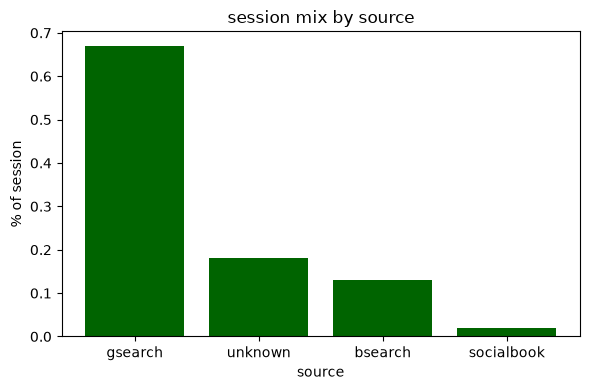

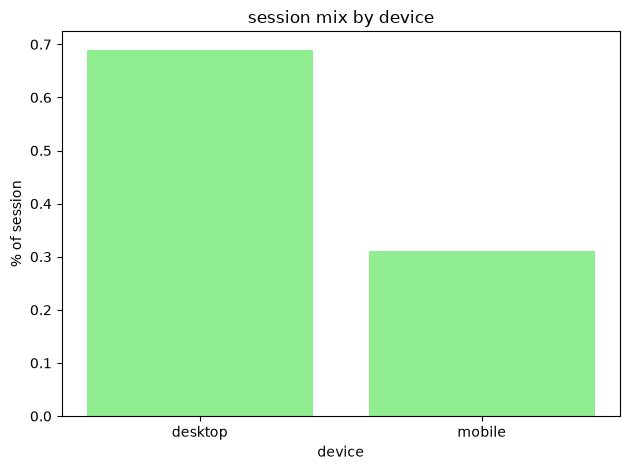

Insight: gsearch sends the most traffic (0.67% of all sessions).
Insight: desktop sends the most traffic (0.69% of all sessions).


In [45]:
#session mix by channel and device
source_mix=sessions['utm_source'].value_counts(normalize=True).round(2).reset_index()
source_mix.columns=['utm_source','pct_of_sessions']
device_mix=sessions['device_type'].value_counts(normalize=True).round(2).reset_index()
device_mix.columns=['device_type','pct_of_sessions']
print('\n=======session mix by source (% of traffic)=========')
print(source_mix.to_string(index=False))
print('\n======session mix by device=======')
print(device_mix.to_string(index=False))

plt.figure(figsize=(6,4))
plt.bar(source_mix['utm_source'],source_mix['pct_of_sessions'],color='darkgreen')
plt.title('session mix by source')
plt.xlabel('source')
plt.ylabel('% of session')
plt.tight_layout()
plt.show()

plt.bar(device_mix['device_type'],device_mix['pct_of_sessions'],color='lightgreen')
plt.title('session mix by device')
plt.xlabel('device')
plt.ylabel('% of session')
plt.tight_layout()
plt.show()

top_traffic_source=source_mix.iloc[0]
top_traffic_device=device_mix.iloc[0]
print(f"Insight: {top_traffic_source['utm_source']} sends the most traffic "
      f"({top_traffic_source['pct_of_sessions']}% of all sessions).")
print(f"Insight: {top_traffic_device['device_type']} sends the most traffic "
      f"({top_traffic_device['pct_of_sessions']}% of all sessions).")


====== revenue by quater======
quarter  price_usd
 2012Q1    2999.40
 2012Q2   17346.53
 2012Q3   34193.16
 2012Q4   74735.05
 2013Q1   66377.27
 2013Q2   88492.83
 2013Q3   94971.59
 2013Q4  136611.84
 2014Q1  169340.31
 2014Q2  215442.52
 2014Q3  226290.65
 2014Q4  328744.92
 2015Q1  298534.80


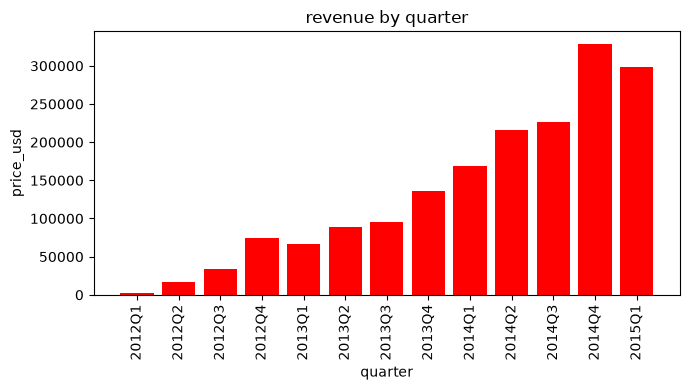

Insight: 2014Q4 is the strongest quarter (328744.92).


In [46]:
# which quarter carries the most revenue
orders['quarter']=orders['created_at'].dt.to_period('Q').astype(str)
revenue_by_quarter=orders.groupby('quarter')['price_usd'].sum().reset_index()
revenue_by_quarter=revenue_by_quarter.sort_values('quarter')

print('\n====== revenue by quater======')
print(revenue_by_quarter.to_string(index=False))

plt.figure(figsize=(7,4))
plt.bar(revenue_by_quarter['quarter'],revenue_by_quarter['price_usd'],color='red')
plt.title('revenue by quarter')
plt.xlabel('quarter')
plt.ylabel('price_usd')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

top_quarter=revenue_by_quarter.loc[revenue_by_quarter['price_usd'].idxmax()]
print(f"Insight: {top_quarter ['quarter']} is the strongest quarter ({top_quarter['price_usd']:.2f}).")

In [47]:
# which month had the sharpest revenue swings  month-over-month?
monthly_revenue['pct_change']=monthly_revenue['price_usd'].pct_change().round(2)
swing_threshold=monthly_revenue['pct_change'].std()
biggest_jump=monthly_revenue.loc[monthly_revenue['pct_change'].idxmax()]
biggest_drop=monthly_revenue.loc[monthly_revenue['pct_change'].idxmin()]
print('\n======= month over month revenue  change (%) =========')
print(monthly_revenue[['months','price_usd','pct_change']].to_string(index=False))
print(f"insights: the sharpest jump was {biggest_jump['months']} ({biggest_jump['pct_change']:+.2f}%),"
      f"the sharpest drop was {biggest_drop['months']} ({biggest_drop['pct_change']:+.2f}%). "
      f"A swing bigger than {swing_threshold:.2f}% is outside the usual month-to-month range.")



======= month over month revenue  change (%) =========
 months  price_usd  pct_change
2012-03    2999.40         NaN
2012-04    4949.01        0.65
2012-05    5398.92        0.09
2012-06    6998.60        0.30
2012-07    8448.31        0.21
2012-08   11397.72        0.35
2012-09   14347.13        0.26
2012-10   18546.29        0.29
2012-11   30893.82        0.67
2012-12   25294.94       -0.18
2013-01   19496.10       -0.23
2013-02   24895.02        0.28
2013-03   19246.15       -0.23
2013-04   27644.47        0.44
2013-05   28544.29        0.03
2013-06   29644.07        0.04
2013-07   30193.96        0.02
2013-08   30393.92        0.01
2013-09   31743.65        0.04
2013-10   36892.62        0.16
2013-11   44891.02        0.22
2013-12   56988.60        0.27
2014-01   55538.89       -0.03
2014-02   67386.52        0.21
2014-03   71335.73        0.06
2014-04   82833.43        0.16
2014-05   93631.27        0.13
2014-06   83733.25       -0.11
2014-07   87232.55        0.04
2014-08   8958

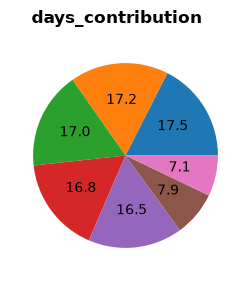

In [48]:
# distribution of order volume across days of the week — are certain days consistently higher or lower
orders['weekdays']=orders['created_at'].dt.day_name()
volume_distribution=orders.groupby('weekdays')['price_usd'].sum().reset_index(name='days_sales')
volume_distribution=volume_distribution.sort_values(by='days_sales',ascending=False)
volume_distribution
volume_distribution['days_contribution']=volume_distribution['days_sales']/sum(volume_distribution['days_sales'])*100
plt.figure(figsize=(7,3))
plt.pie(x=volume_distribution['days_contribution'],autopct='%1.1f')
plt.suptitle('days_contribution',fontweight='bold')
plt.show()

### Diagnostic analysis (why it happened)
-- Diagnostic analysis asks questions about those numbers by comparing groups.

In [49]:
merged_grp=sessions.merge(orders[['order_id','website_session_id']],on='website_session_id',how='left')


======conversion by source=======
utm_source  sessions  orders  conversion_rate_pct
   unknown     83328    6118                 7.34
   bsearch     62823    4519                 7.19
   gsearch    316035   21333                 6.75
socialbook     10685     343                 3.21


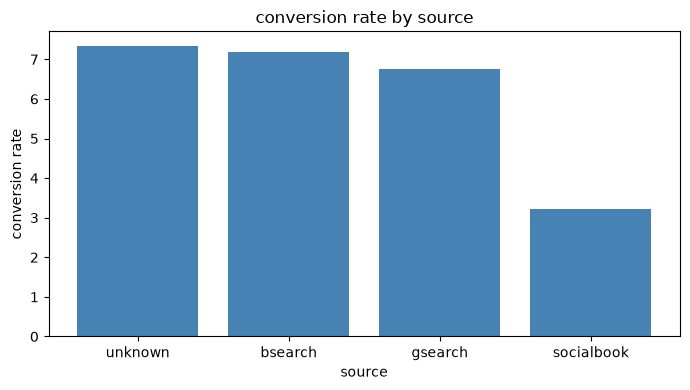

Insight: unknown converts best (7.34%), unknown converts worst (7.34%).


In [50]:
# conversion by source  
conversion_by_source=merged_grp.groupby('utm_source').agg(sessions=('website_session_id','nunique'),orders=('order_id','nunique')).reset_index()
conversion_by_source['conversion_rate_pct']=(conversion_by_source['orders']/conversion_by_source['sessions']*100).round(2)
conversion_by_source=conversion_by_source.sort_values('conversion_rate_pct',ascending=False)
print('\n======conversion by source=======')
print(conversion_by_source.to_string(index=False))

plt.figure(figsize=(7,4))
plt.bar(conversion_by_source['utm_source'],conversion_by_source['conversion_rate_pct'],color='steelblue')
plt.title('conversion rate by source')
plt.xlabel('source')
plt.ylabel('conversion rate')
plt.tight_layout()
plt.show()

best_conv_source=conversion_by_source.iloc[0]
worst_conv_source=conversion_by_source.iloc[0]
print(f"Insight: {best_conv_source['utm_source']} converts best ({best_conv_source['conversion_rate_pct']}%), "
      f"{worst_conv_source['utm_source']} converts worst ({worst_conv_source['conversion_rate_pct']}%).")


======conversion by source=======
device_type  sessions  orders  conversion_rate_pct
    desktop    327027   27805                 8.50
     mobile    145844    4508                 3.09


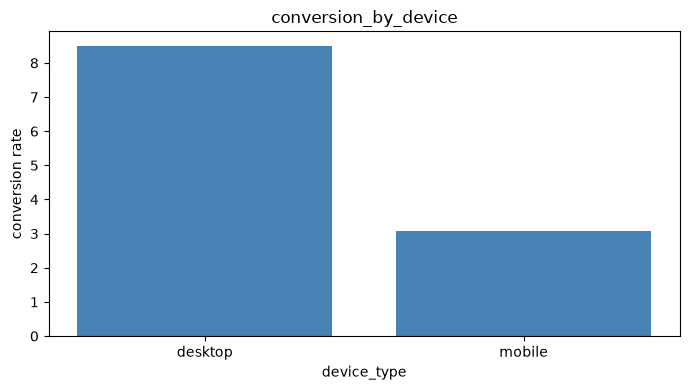

Insight: desktop converts best (8.5%), desktop converts worst (8.5%).


In [51]:
# conversion by device  
conversion_by_device=merged_grp.groupby('device_type').agg(sessions=('website_session_id','nunique'),orders=('order_id','nunique')).reset_index()
conversion_by_device['conversion_rate_pct']=(conversion_by_device['orders']/conversion_by_device['sessions']*100).round(2)
conversion_by_device=conversion_by_device.sort_values('conversion_rate_pct',ascending=False)
print('\n======conversion by source=======')
print(conversion_by_device.to_string(index=False))

plt.figure(figsize=(7,4))
plt.bar(conversion_by_device['device_type'],conversion_by_device['conversion_rate_pct'],color='steelblue')
plt.title('conversion_by_device')
plt.xlabel('device_type')
plt.ylabel('conversion rate')
plt.tight_layout()
plt.show()

best_conv_device=conversion_by_device.iloc[0]
worst_conv_device=conversion_by_device.iloc[0]
print(f"Insight: {best_conv_device['device_type']} converts best ({best_conv_device['conversion_rate_pct']}%), "
      f"{worst_conv_device['device_type']} converts worst ({worst_conv_device['conversion_rate_pct']}%).")


====== repeat vs new visitors========
 is_repeat_session  sessions  orders  conversion_rate_pct
                 1     78553    6149                 7.83
                 0    394318   26164                 6.64


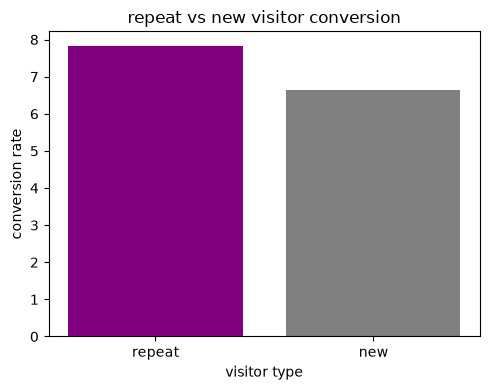

Insight: Repeat visitors convert at 7.83% vs 6.64% for new visitors — a 1.19 point gap.


In [52]:
# repeat vs new visitor conversion 
repeat_vs_new=merged_grp.groupby('is_repeat_session').agg(
    sessions=('website_session_id','nunique'),orders=('order_id','nunique'),
).reset_index()
repeat_vs_new['conversion_rate_pct']=(repeat_vs_new['orders']/repeat_vs_new['sessions']*100).round(2)
repeat_vs_new=repeat_vs_new.sort_values('conversion_rate_pct',ascending=False)
print('\n====== repeat vs new visitors========')
print(repeat_vs_new.to_string(index=False))

labels=['repeat' if v==1 else 'new' for v in repeat_vs_new['is_repeat_session']]
plt.figure(figsize=(5,4))
plt.bar(labels,repeat_vs_new['conversion_rate_pct'],color=['purple','grey'])
plt.title('repeat vs new visitor conversion')
plt.xlabel('visitor type')
plt.ylabel('conversion rate')
plt.tight_layout()
plt.show()

repeat_row=repeat_vs_new[repeat_vs_new['is_repeat_session']==1].iloc[0]
new_row=repeat_vs_new[repeat_vs_new['is_repeat_session']==0].iloc[0]
gap=repeat_row['conversion_rate_pct']-new_row['conversion_rate_pct']
print(f"Insight: Repeat visitors convert at {repeat_row['conversion_rate_pct']}% vs "
      f"{new_row['conversion_rate_pct']}% for new visitors — a {gap:.2f} point gap.")


======= refund rate by pproduct =======
              product_name  units_sold  units_refunded  refund_amount  refund_rate_pct
  The Birthday Sugar Panda        4985             301       15046.99             6.04
    The Original Mr. Fuzzy       24226            1237       61837.63             5.11
     The Forever Love Bear        5796             129        6448.71             2.23
The Hudson River Mini bear        5018              64        3199.36             1.28


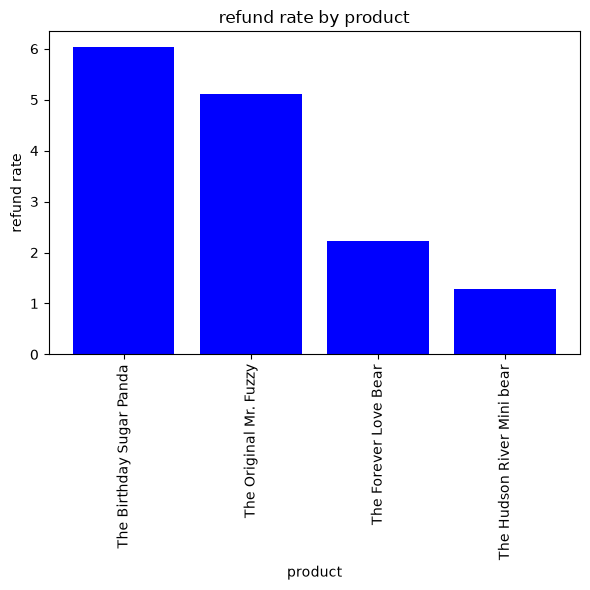

Insight: The Birthday Sugar Panda has the highest refund rate (6.04% of units sold).


In [53]:
# refund rate by product 
items_with_product=order_items.merge(products,on='product_id')
items_with_refund=items_with_product.merge(
    refunds[['order_item_id','refund_amount_usd']],
    on='order_item_id',how='left'
)
items_with_refund['was_refunded']=items_with_refund['refund_amount_usd'].notna()
refund_rate_by_product=items_with_refund.groupby('product_name').agg(
    units_sold=('order_item_id','nunique'),
    units_refunded=('was_refunded','sum'),
    refund_amount=('refund_amount_usd','sum')
).reset_index()
refund_rate_by_product['refund_rate_pct']=(
    refund_rate_by_product['units_refunded']/refund_rate_by_product['units_sold']*100).round(2)
refund_rate_by_product=refund_rate_by_product.sort_values('refund_rate_pct',ascending=False)
print('\n======= refund rate by pproduct =======')
print(refund_rate_by_product.to_string(index=False))

plt.figure(figsize=(6,6))
plt.bar(refund_rate_by_product['product_name'],refund_rate_by_product['refund_rate_pct'],color='blue')
plt.title('refund rate by product')
plt.xlabel('product')
plt.ylabel('refund rate')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

worst_refund=refund_rate_by_product.iloc[0]
print(f"Insight: {worst_refund['product_name']} has the highest refund rate "
      f"({worst_refund['refund_rate_pct']}% of units sold).")


======funnel drop off========
                  stage  sessions  pct_of_landed
landed(session started)    472871         100.00
            viewed page    472871         100.00
        placed an order     32313           6.83


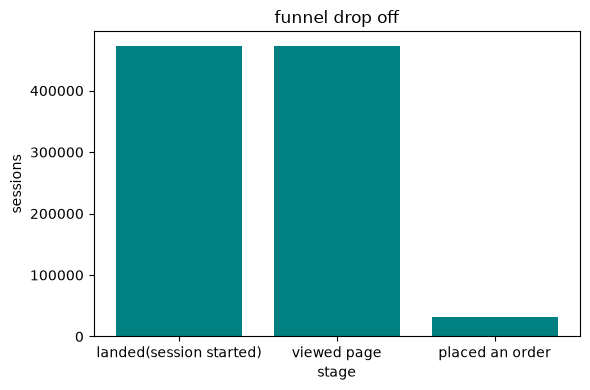

insights: the biggest drop-off happens between 'viewed a page->placed an order'.


In [54]:
# funnel drop off
total_session_f=sessions['website_session_id'].nunique()
sessions_with_pageview=website_pageviews['website_session_id'].nunique()
sessions_with_order=orders['website_session_id'].nunique()
funnel=pd.DataFrame({
    'stage':["landed(session started)","viewed page","placed an order"],
    'sessions':[total_session_f,sessions_with_pageview,sessions_with_order],
})
funnel['pct_of_landed']=(funnel['sessions']/total_session_f*100).round(2)
print('\n======funnel drop off========')
print(funnel.to_string(index=False))
plt.figure(figsize=(6,4))
plt.bar(funnel['stage'],funnel['sessions'],color='teal')
plt.title('funnel drop off')
plt.xlabel('stage')
plt.ylabel('sessions')
plt.tight_layout()
plt.show()

drop_pageview=100-funnel.loc[1,'pct_of_landed']
drop_order=funnel.loc[1,'pct_of_landed']-funnel.loc[2,'pct_of_landed']
biggest_drop_stage='landed->viewed a page' if drop_pageview>drop_order else "viewed a page->placed an order"
print(f"insights: the biggest drop-off happens between '{biggest_drop_stage}'.")


===== correlation (orders level numeric fields)=======
                 items_purchased  price_usd  cogs_usd
items_purchased              NaN        NaN       NaN
price_usd                    NaN      1.000     0.953
cogs_usd                     NaN      0.953     1.000


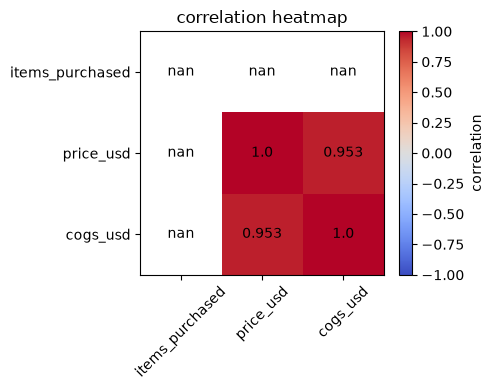

In [55]:
## correlation check 
numeric_cols=['items_purchased','price_usd','cogs_usd']
correlation=orders[numeric_cols].corr().round(3)
print('\n===== correlation (orders level numeric fields)=======')
print(correlation.to_string())
plt.figure(figsize=(5,4))
plt.imshow(correlation,cmap='coolwarm',vmin=-1,vmax=1)
plt.colorbar(label='correlation')
plt.xticks(range(len(numeric_cols)),numeric_cols,rotation=45)
plt.yticks(range(len(numeric_cols)),numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j,i,correlation.iloc[i,j],ha='center',va='center',color='black')
plt.title('correlation heatmap')
plt.tight_layout()
plt.show()



### predictive analysis -what's likely to happen

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,roc_auc_score,recall_score,f1_score,confusion_matrix,classification_report)
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [57]:
# Build session-level dataset: one row per session, label = converted ---
converted_ids=set(orders['website_session_id'].dropna())
sessions['converted']=sessions['website_session_id'].isin(converted_ids).astype(int)
categorical_features=['utm_source','utm_campaign','device_type']
binary_features=['is_repeat_session']
target='converted'
keep_cols=['website_session_id']+categorical_features+binary_features+[target]
dataset=sessions[keep_cols].dropna(subset=categorical_features+binary_features)

print('\n session dataset shape:',dataset.shape)
print('baseline conversion rate:{:.2f}%'.format(dataset[target].mean()*100))



 session dataset shape: (472871, 6)
baseline conversion rate:6.83%


In [58]:
# ---  Feature engineering: one-hot encode categoricals, keep binary as-is ---
# OneHotEncoder (not LabelEncoder) because utm_source/device_type/utm_campaign
# have no natural order — LabelEncoder would wrongly imply one category is
# "greater than" another.

X=dataset[categorical_features+binary_features]
y=dataset[target]

preprocessor=ColumnTransformer(transformers=[
    ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features)],remainder='passthrough') # passes is_repeat_session through unchanged

#Train/test split (stratified — conversion is a minority class) ---
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

# Fit logistic regression ---
# class_weight="balanced" matters — most sessions do NOT convert, and an
# unweighted model would just predict "no" for every session.

pipeline=Pipeline(steps=[
    ('preprocess',preprocessor),
    ('model',LogisticRegression(max_iter=1000,class_weight='balanced')),
])
pipeline.fit(X_train,y_train)

# Evaluate: accuracy, ROC-AUC, precision, recall, F1, confusion matrix ---
y_pred=pipeline.predict(X_test)
y_proba=pipeline.predict_proba(X_test)[:,1]

accuracy=accuracy_score(y_test,y_pred)
roc_auc=roc_auc_score(y_test,y_proba)
precision=precision_score(y_test,y_pred,zero_division=0)
recall=recall_score(y_test,y_pred,zero_division=0)
f1=f1_score(y_test,y_pred,zero_division=0)
cm=confusion_matrix(y_test,y_pred)

print('\n ====== model evaluation =====')
print('train rows:',len(X_train), "| test rows:",len(X_test))
print('Accuracy:',round(accuracy,4))
print('Precision:',round(precision,4))
print('Roc-auc-score:',round(roc_auc,4))
print('Recall:',round(recall,4))
print('F1:',round(f1,4))
print('"\nConfusion matrix [[TN, FP], [FN, TP]]:"):')
print(cm)
print('\n'+ classification_report(y_test,y_pred,zero_division=0))


 ====== model evaluation =====
train rows: 378296 | test rows: 94575
Accuracy: 0.369
Precision: 0.0857
Roc-auc-score: 0.6077
Recall: 0.8519
F1: 0.1558
"
Confusion matrix [[TN, FP], [FN, TP]]:"):
[[29396 58716]
 [  957  5506]]

              precision    recall  f1-score   support

           0       0.97      0.33      0.50     88112
           1       0.09      0.85      0.16      6463

    accuracy                           0.37     94575
   macro avg       0.53      0.59      0.33     94575
weighted avg       0.91      0.37      0.47     94575



### bulid streamlit

In [60]:
import streamlit as st
import joblib
import os
import pickle

In [61]:
##Save the fitted model so it can be reused in the web app ---
with open("conversion_model.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Model saved to conversion_model.pkl")
print("\nPipeline complete.")

Model saved to conversion_model.pkl

Pipeline complete.


In [63]:
with open("conversion_model.pkl", "rb") as f:
    model = pickle.load(f)